# Complexity-01 — Compter des pas

**Navigation** : [Index de la série](README.md) | [Complexity-02 — Vérifier ou trouver >>](Complexity-02-P-NP-Reduction.ipynb)

> **Public : Découverte.** Premier notebook de la série `Complexity/`. Il ne suppose aucune
> notion de théorie de la complexité : tout ce qu'il utilise est construit ici, cellule par cellule.

## Ce que ce notebook suppose

- lire un programme Python simple : boucles `for` et `while`, fonctions, listes, dictionnaires ;
- savoir ce que font un tri et une recherche dans une liste.

Rien d'autre : ni notation $O$, ni machine de Turing, ni classe de complexité.

## Ce que vous saurez faire à la fin

1. expliquer pourquoi on mesure le coût d'un algorithme en **nombre de pas** plutôt qu'en secondes ;
2. définir la **taille d'une entrée** et la **fonction de coût** d'un algorithme ;
3. faire tourner une petite machine de Turing et compter ses pas ;
4. reconnaître à la mesure trois croissances, $n \log n$, $n^2$ et $2^n$, grâce au **test du doublement** ;
5. dire, pour chacune, quelle taille d'entrée reste traitable en une seconde, une minute, un jour.

**Durée estimée** : 45 minutes.

In [1]:
import math
import time

import numpy as np
import matplotlib.pyplot as plt

## 1. Le chronomètre ment un peu

Le réflexe naturel pour savoir si un programme est rapide, c'est de le chronométrer. Faisons-le :
la même fonction, sur la même liste, exécutée sept fois de suite.

La fonction `somme` additionne un million d'entiers. Elle tient aussi un compteur `pas`,
augmenté de 1 à chaque addition : c'est la mesure que ce notebook va opposer au chronomètre.
Si le temps mesuré était une propriété du programme, les sept essais devraient afficher le
même nombre de millisecondes. Regardez ce qui varie d'un essai à l'autre, et ce qui ne varie pas.

In [2]:
def somme(liste):
    total = 0
    pas = 0
    for x in liste:
        total += x
        pas += 1          # un pas = une addition
    return total, pas


donnees = list(range(1_000_000))
chronos = []
for essai in range(7):
    t0 = time.perf_counter()
    total, pas = somme(donnees)
    chronos.append(time.perf_counter() - t0)

for essai, t in enumerate(chronos, start=1):
    print(f"essai {essai} : {t * 1000:7.2f} ms   |   {pas:,} pas".replace(",", " "))
print()
print(f"ecart chrono le plus lent / le plus rapide : x{max(chronos) / min(chronos):.2f}")
print(f"nombre de pas : identique aux 7 essais ({pas:,})".replace(",", " "))

essai 1 :   67.89 ms   |   1 000 000 pas
essai 2 :   35.51 ms   |   1 000 000 pas
essai 3 :   28.96 ms   |   1 000 000 pas
essai 4 :   29.56 ms   |   1 000 000 pas
essai 5 :   26.01 ms   |   1 000 000 pas
essai 6 :   27.27 ms   |   1 000 000 pas
essai 7 :   28.33 ms   |   1 000 000 pas

ecart chrono le plus lent / le plus rapide : x2.61
nombre de pas : identique aux 7 essais (1 000 000)


**Lecture.** Les sept chronos ne coïncident pas : l'écart affiché dépend de ce que fait la
machine au même moment (autres programmes, fréquence du processeur, mémoire cache). Sur un autre
ordinateur, ou dans un autre langage, ils seraient tous différents. Le **nombre de pas**, lui, est
le même aux sept essais — et il serait le même sur n'importe quelle machine : c'est une
propriété de l'**algorithme**, pas de l'ordinateur.

C'est tout le point de départ de la théorie de la complexité : on ne demande pas « combien de
secondes ? » mais « **combien de pas** ? ». Le chronomètre reste utile pour confirmer une mesure ;
il ne sert pas à la définir.

## 2. Taille d'entrée et fonction de coût

Un algorithme ne coûte pas « 1000 pas » dans l'absolu : son coût dépend de l'entrée qu'on lui
donne. On résume une entrée par sa **taille** $n$ — le nombre d'éléments d'une liste, le nombre de
caractères d'un mot — et on étudie comment le nombre de pas évolue quand $n$ grandit.

Premier exemple : chercher une valeur dans une liste non triée en la parcourant du début à la fin.
Un pas = une comparaison.

In [3]:
def recherche_lineaire(liste, x):
    comparaisons = 0
    for i, v in enumerate(liste):
        comparaisons += 1
        if v == x:
            return i, comparaisons
    return -1, comparaisons


print(f"{'n':>7} | {'meilleur cas':>12} | {'pire cas':>9} | pire cas / n")
print("-" * 48)
for n in (10, 100, 1_000, 10_000, 100_000):
    liste = list(range(n))
    _, meilleur = recherche_lineaire(liste, 0)        # la valeur est en tete
    _, pire = recherche_lineaire(liste, -1)           # la valeur est absente
    print(f"{n:>7} | {meilleur:>12} | {pire:>9} | {pire / n:>11.2f}")

      n | meilleur cas |  pire cas | pire cas / n
------------------------------------------------
     10 |            1 |        10 |        1.00
    100 |            1 |       100 |        1.00
   1000 |            1 |      1000 |        1.00
  10000 |            1 |     10000 |        1.00
 100000 |            1 |    100000 |        1.00


**Lecture.** Pour une même taille $n$, le coût varie selon l'entrée : **1** comparaison si la
valeur est en tête, **$n$** si elle est absente. On retient en général le **pire cas** : la
**fonction de coût** $T(n)$ est le plus grand nombre de pas que l'algorithme peut faire sur une
entrée de taille $n$. Ici la dernière colonne vaut exactement 1 : $T(n) = n$. La recherche
linéaire a un coût **linéaire** — doubler la liste double le travail dans le pire cas.

Ce vocabulaire suffit pour la suite : **taille** $n$, **pas**, **pire cas**, **fonction de coût** $T(n)$.

## 3. Une machine qui compte ses pas : la machine de Turing

« Un pas » d'un programme Python reste un peu flou : une addition, un appel de fonction, une
lecture de liste coûtent-ils la même chose ? Pour rendre la notion **exacte**, les informaticiens
utilisent un modèle de machine où le pas est défini sans ambiguïté : la **machine de Turing**
(Alan Turing, 1936).

- un **ruban** infini découpé en cases, chaque case porte un symbole (`_` = case vide) ;
- une **tête** de lecture posée sur une case ;
- un **état** courant, pris dans une liste finie ;
- une **table de transitions** : pour chaque couple (état, symbole lu), elle dit quel symbole
  écrire, dans quel sens déplacer la tête (`L` gauche, `R` droite, `S` rester) et dans quel état passer.

**Un pas = une transition.** La machine s'arrête quand elle atteint un état acceptant, ou quand
aucune transition ne s'applique (elle rejette). Le simulateur ci-dessous accepte plusieurs rubans
(on n'en utilisera qu'un ici) et compte ses pas.

Première machine : ajouter 1 à un nombre écrit en binaire. Elle va au bout du mot, puis revient
vers la gauche en propageant la retenue.

In [4]:
class Ruban:
    # Ruban infini aux deux extremites, symbole blanc '_'.
    def __init__(self, mot=""):
        self.cellules = {i: c for i, c in enumerate(mot)}
        self.tete = 0

    def lire(self):
        return self.cellules.get(self.tete, "_")

    def ecrire(self, c):
        self.cellules[self.tete] = c

    def deplacer(self, d):
        self.tete += 1 if d == "R" else (-1 if d == "L" else 0)


class MachineTuring:
    # Machine a k rubans avec compteur de pas.
    # run() retourne l'etat d'arret : un etat acceptant, ou None (blocage = rejet, ou budget epuise).
    def __init__(self, k_rubans, transitions, etat_initial, etats_acceptants):
        self.k = k_rubans
        self.delta = transitions  # (etat, symboles lus) -> (nouvel etat, [(ecriture, deplacement)] * k)
        self.q0 = etat_initial
        self.F = set(etats_acceptants)
        self.pas = 0

    def run(self, mot, max_pas=100_000):
        rubans = [Ruban(mot) if i == 0 else Ruban() for i in range(self.k)]
        etat = self.q0
        self.pas = 0
        while etat not in self.F:
            if self.pas >= max_pas:
                return None, rubans  # budget epuise
            lus = tuple(r.lire() for r in rubans)
            if (etat, lus) not in self.delta:
                return None, rubans  # blocage : rejet
            etat, ecritures = self.delta[(etat, lus)]
            for r, (c, d) in zip(rubans, ecritures):
                r.ecrire(c)
                r.deplacer(d)
            self.pas += 1
        return etat, rubans


def lire_ruban(r):
    # Contenu du ruban, de la case la plus a gauche a la plus a droite, sans les blancs du bord.
    if not r.cellules:
        return ""
    debut, fin = min(r.cellules), max(r.cellules)
    return "".join(r.cellules.get(i, "_") for i in range(debut, fin + 1)).strip("_")


# --- Machine A : increment binaire, 1 ruban ---
inc = MachineTuring(
    1,
    {
        ("q0", ("0",)): ("q0", (("0", "R"),)),   # aller au bout du mot
        ("q0", ("1",)): ("q0", (("1", "R"),)),
        ("q0", ("_",)): ("q1", (("_", "L"),)),   # fin du mot : revenir d'une case
        ("q1", ("1",)): ("q1", (("0", "L"),)),   # 1 + retenue = 0, la retenue continue
        ("q1", ("0",)): ("qF", (("1", "S"),)),   # 0 + retenue = 1, termine
        ("q1", ("_",)): ("qF", (("1", "S"),)),   # debordement : nouveau chiffre en tete
    },
    "q0", ["qF"],
)

for mot, attendu in [("1011", "1100"), ("0", "1"), ("111", "1000")]:
    etat, rubans = inc.run(mot)
    resultat = lire_ruban(rubans[0])
    assert resultat == attendu, (mot, resultat)
    print(f"increment({mot!r:>7}) -> {resultat!r:>7} en {inc.pas} pas")

increment( '1011') ->  '1100' en 8 pas
increment(    '0') ->     '1' en 3 pas
increment(  '111') ->  '1000' en 8 pas


**Lecture.** La machine donne le bon résultat sur les trois mots (l'`assert` le vérifie) et le
nombre de pas est **exact** : pour `'1011'`, 5 pas pour aller au bout du mot (4 chiffres, puis la
case vide) et 3 pas pour revenir en propageant la retenue. Aucun chronomètre n'intervient.

Deuxième machine, plus coûteuse : reconnaître un **palindrome** (un mot qui se lit pareil dans les
deux sens, comme `0110`). Avec une seule tête, la machine fait des allers-retours : elle raye le
premier symbole, court jusqu'au dernier, vérifie qu'il est identique, le raye, revient au début,
et recommence.

In [5]:
# --- Machine B : palindrome sur {0,1}, 1 ruban, allers-retours ---
# Comparer premier et dernier caractere, les rayer ('x'), recommencer.
# Rejet = etat puits 'rejeter' sans transition sortante -> blocage.
D = {}
D[("scan", ("0",))] = ("marque0", (("x", "R"),))
D[("scan", ("1",))] = ("marque1", (("x", "R"),))
D[("scan", ("x",))] = ("scan", (("x", "R"),))
D[("scan", ("_",))] = ("fin", (("_", "S"),))          # ruban epuise -> accepter
D[("marque0", ("0",))] = ("marque0", (("0", "R"),))
D[("marque0", ("1",))] = ("marque0", (("1", "R"),))
D[("marque0", ("x",))] = ("verif0", (("x", "L"),))
D[("marque0", ("_",))] = ("verif0", (("_", "L"),))
D[("marque1", ("0",))] = ("marque1", (("0", "R"),))
D[("marque1", ("1",))] = ("marque1", (("1", "R"),))
D[("marque1", ("x",))] = ("verif1", (("x", "L"),))
D[("marque1", ("_",))] = ("verif1", (("_", "L"),))
D[("verif0", ("0",))] = ("retour", (("x", "L"),))      # dernier = 0 : rayer
D[("verif1", ("1",))] = ("retour", (("x", "L"),))      # dernier = 1 : rayer
D[("verif0", ("1",))] = ("rejeter", (("1", "S"),))     # different -> puits
D[("verif1", ("0",))] = ("rejeter", (("0", "S"),))
D[("verif0", ("x",))] = ("fin", (("x", "S"),))         # un seul caractere restant
D[("verif1", ("x",))] = ("fin", (("x", "S"),))
for s in ("0", "1", "x"):
    D[("retour", (s,))] = ("retour", ((s, "L"),))
D[("retour", ("_",))] = ("scan", (("_", "R"),))        # revenir au debut
pal = MachineTuring(1, D, "scan", ["fin"])

# Verification de correction avant toute mesure
for mot, attendu in [("0110", "fin"), ("0100", None), ("0", "fin"), ("0110110", "fin")]:
    etat, _ = pal.run(mot)
    assert etat == attendu, f"pal({mot}) -> {etat}, attendu {attendu}"
print("verifications : pal accepte 0110, 0110110, 0 ; rejette 0100 (blocage). OK")

print()
print(f"{'n':>4} | {'pas inc':>8} | {'pas pal':>8} | {'pal / inc':>9} | {'pal / n^2':>9}")
print("-" * 52)
for demi in (4, 8, 16, 32, 64):
    moitie = "".join("01"[(i * 7) % 2] for i in range(demi))
    mot = moitie + moitie[::-1]        # palindrome de longueur n = 2 * demi
    n = len(mot)
    inc.run(mot)
    pal.run(mot, max_pas=500_000)
    print(f"{n:>4} | {inc.pas:>8} | {pal.pas:>8} | {pal.pas / inc.pas:>8.2f}x | {pal.pas / n ** 2:>9.3f}")

verifications : pal accepte 0110, 0110110, 0 ; rejette 0100 (blocage). OK

   n |  pas inc |  pas pal | pal / inc | pal / n^2
----------------------------------------------------
   8 |       10 |       69 |     6.90x |     1.078
  16 |       18 |      233 |    12.94x |     0.910
  32 |       34 |      849 |    24.97x |     0.829
  64 |       66 |     3233 |    48.98x |     0.789
 128 |      130 |    12609 |    96.99x |     0.770


**Lecture.** Sur les mêmes mots, les deux machines ne vivent pas dans le même monde :

- la machine d'incrément fait $n + 2$ pas (colonne `pas inc`) : un aller, une retenue courte. Son
  coût est **linéaire** ;
- la machine palindrome fait de l'ordre de $n^2$ pas : la dernière colonne, `pal / n^2`, décroît
  de moins en moins vite (l'écart d'une ligne à la suivante est à peu près divisé par deux) et
  converge vers une constante. Son coût est **quadratique** : chaque symbole rayé coûte un
  aller-retour sur tout le mot.

Conséquence mesurée dans la colonne `pal / inc` : l'écart entre les deux machines **double** à
chaque doublement de $n$. Ce n'est pas une question de constante ou de machine plus rapide : c'est
la **forme** de la croissance qui diffère. C'est cette forme que la théorie de la complexité étudie.

## 4. Trois croissances, un test : doubler $n$

Revenons à Python, en comptant les pas nous-mêmes, sur trois algorithmes aux comportements très
différents :

| Algorithme | Ce qu'il fait | Un pas = |
|---|---|---|
| **tri fusion** | coupe la liste en deux, trie chaque moitié, fusionne | une comparaison |
| **paire la plus proche** | compare toutes les paires de nombres | une comparaison |
| **tous les sous-ensembles** | examine chaque sous-ensemble d'une liste de poids et calcule sa somme | un sous-ensemble examiné |

Le **test du doublement** consiste à mesurer $T(2n) / T(n)$ : combien de fois plus de travail
quand l'entrée double ?

In [6]:
def tri_fusion(liste, compteur):
    if len(liste) <= 1:
        return liste
    m = len(liste) // 2
    g = tri_fusion(liste[:m], compteur)
    d = tri_fusion(liste[m:], compteur)
    fusion, i, j = [], 0, 0
    while i < len(g) and j < len(d):
        compteur[0] += 1
        if g[i] <= d[j]:
            fusion.append(g[i])
            i += 1
        else:
            fusion.append(d[j])
            j += 1
    fusion.extend(g[i:])
    fusion.extend(d[j:])
    return fusion


def paire_la_plus_proche(liste, compteur):
    meilleur = math.inf
    for i in range(len(liste)):
        for j in range(i + 1, len(liste)):
            compteur[0] += 1
            meilleur = min(meilleur, abs(liste[i] - liste[j]))
    return meilleur


def sommes_de_tous_les_sous_ensembles(poids, compteur):
    # sommes[masque] = somme des poids choisis par les bits de masque ;
    # chaque somme se deduit d'une somme deja calculee en retirant le bit le plus bas.
    sommes = [0] * (2 ** len(poids))
    for masque in range(1, 2 ** len(poids)):
        bas = masque & -masque
        sommes[masque] = sommes[masque ^ bas] + poids[bas.bit_length() - 1]
        compteur[0] += 1
    compteur[0] += 1  # le sous-ensemble vide
    return sommes


def compter(algo, n, graine=0):
    rng = np.random.default_rng(graine)
    donnees = rng.integers(0, 10 ** 6, size=n).tolist()
    compteur = [0]
    resultat = algo(donnees, compteur)
    if algo is tri_fusion:
        assert resultat == sorted(donnees)       # le tri est correct
    return compteur[0]


def test_doublement(algo, tailles):
    pas = [compter(algo, n) for n in tailles]
    for k, (n, p) in enumerate(zip(tailles, pas)):
        rapport = "" if k == 0 else f"x{p / pas[k - 1]:.2f}"
        print(f"   n = {n:>6} : {p:>12,} pas   {rapport}".replace(",", " "))
    return pas


print("tri fusion (n double a chaque ligne)")
pas_tri = test_doublement(tri_fusion, [1_000, 2_000, 4_000, 8_000, 16_000])
print("paire la plus proche (n double a chaque ligne)")
pas_paires = test_doublement(paire_la_plus_proche, [250, 500, 1_000, 2_000])
print("tous les sous-ensembles (n double a chaque ligne)")
pas_sous = test_doublement(sommes_de_tous_les_sous_ensembles, [5, 10, 20])
print("tous les sous-ensembles (n augmente de 1 a chaque ligne)")
pas_sous_1 = test_doublement(sommes_de_tous_les_sous_ensembles, [16, 17, 18, 19, 20])

tri fusion (n double a chaque ligne)
   n =   1000 :        8 717 pas   
   n =   2000 :       19 433 pas   x2.23
   n =   4000 :       42 828 pas   x2.20
   n =   8000 :       93 677 pas   x2.19
   n =  16000 :      203 322 pas   x2.17
paire la plus proche (n double a chaque ligne)


   n =    250 :       31 125 pas   
   n =    500 :      124 750 pas   x4.01
   n =   1000 :      499 500 pas   x4.00
   n =   2000 :    1 999 000 pas   x4.00
tous les sous-ensembles (n double a chaque ligne)
   n =      5 :           32 pas   
   n =     10 :        1 024 pas   x32.00
   n =     20 :    1 048 576 pas   x1024.00
tous les sous-ensembles (n augmente de 1 a chaque ligne)


   n =     16 :       65 536 pas   
   n =     17 :      131 072 pas   x2.00
   n =     18 :      262 144 pas   x2.00
   n =     19 :      524 288 pas   x2.00
   n =     20 :    1 048 576 pas   x2.00


**Lecture.** Le test du doublement sépare nettement les trois algorithmes :

- **tri fusion** : quand $n$ double, le travail fait un peu plus que doubler (rapports affichés
  légèrement au-dessus de 2). C'est la signature de $n \log n$ : $2n \log(2n) / (n \log n) = 2 \cdot (1 + 1/\log_2 n)$ ;
- **paire la plus proche** : le travail est multiplié par **4** exactement à chaque doublement,
  car il y a $n(n-1)/2$ paires. C'est la signature de $n^2$ ;
- **tous les sous-ensembles** : le test du doublement n'a plus de sens, le rapport explose
  (×32 puis ×1024). La bonne question devient « que se passe-t-il quand $n$ augmente de **un** ? »
  — et la dernière table répond : le travail **double** à chaque élément ajouté. C'est la
  signature de $2^n$.

Un graphique en échelles logarithmiques rend la différence visible d'un coup d'œil : un coût
polynomial $n^k$ y devient une **droite de pente $k$**, alors qu'une exponentielle n'est une
droite d'aucune pente.

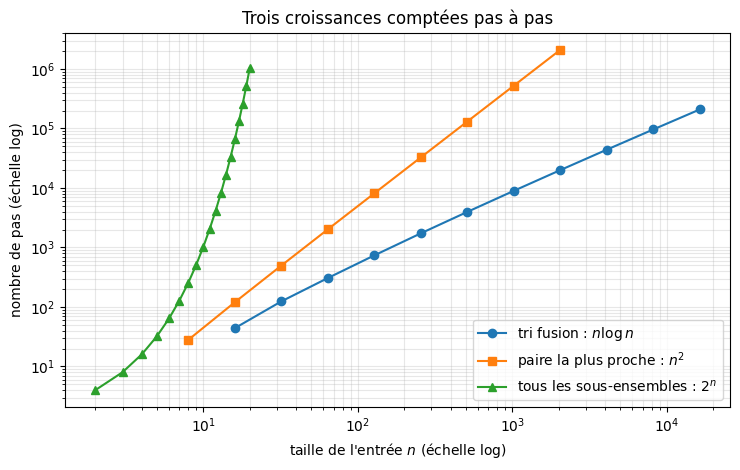

pente log-log du tri fusion          : 1.21  (un peu plus que 1 : le facteur log n)
pente log-log de la paire la + proche : 2.02  (2 : quadratique)
pentes locales des sous-ensembles (entre deux tailles successives) :
   1.7  3.8  5.9  8.0  10.0  12.1   -> la pente ne cesse de croitre


In [7]:
tailles_tri = [2 ** k for k in range(4, 15)]
tailles_paires = [2 ** k for k in range(3, 12)]
tailles_sous = list(range(2, 21))

courbe_tri = [compter(tri_fusion, n) for n in tailles_tri]
courbe_paires = [compter(paire_la_plus_proche, n) for n in tailles_paires]
courbe_sous = [compter(sommes_de_tous_les_sous_ensembles, n) for n in tailles_sous]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.loglog(tailles_tri, courbe_tri, "o-", label=r"tri fusion : $n \log n$")
ax.loglog(tailles_paires, courbe_paires, "s-", label=r"paire la plus proche : $n^2$")
ax.loglog(tailles_sous, courbe_sous, "^-", label=r"tous les sous-ensembles : $2^n$")
ax.set_xlabel("taille de l'entrée $n$ (échelle log)")
ax.set_ylabel("nombre de pas (échelle log)")
ax.set_title("Trois croissances comptées pas à pas")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

pente_tri = np.polyfit(np.log(tailles_tri), np.log(courbe_tri), 1)[0]
pente_paires = np.polyfit(np.log(tailles_paires), np.log(courbe_paires), 1)[0]
print(f"pente log-log du tri fusion          : {pente_tri:.2f}  (un peu plus que 1 : le facteur log n)")
print(f"pente log-log de la paire la + proche : {pente_paires:.2f}  (2 : quadratique)")
print("pentes locales des sous-ensembles (entre deux tailles successives) :")
pentes_locales = [
    math.log(courbe_sous[k + 1] / courbe_sous[k]) / math.log(tailles_sous[k + 1] / tailles_sous[k])
    for k in range(0, len(tailles_sous) - 1, 3)
]
print("   " + "  ".join(f"{p:.1f}" for p in pentes_locales) + "   -> la pente ne cesse de croitre")

**Lecture.** Sur le graphique, le tri fusion et la paire la plus proche sont des droites, avec les
pentes affichées : un peu plus de 1 pour $n \log n$, 2 pour $n^2$. La courbe des sous-ensembles se
redresse sans cesse — ses pentes locales augmentent d'un point de mesure à l'autre. Aucun polynôme,
même de degré 10 ou 100, ne finit par la suivre : **une exponentielle dépasse tout polynôme**.

On dit qu'un algorithme a un coût **polynomial** si son nombre de pas est au plus de l'ordre de
$n^k$ pour un $k$ fixe ($n$, $n \log n$, $n^2$, $n^3$…), et **exponentiel** s'il est de l'ordre de
$2^n$ ou plus. Cette frontière est la plus importante de toute la série.

## 5. Ce que « croître comme » veut dire en pratique

Les constantes comptent peu face à la forme de la croissance. Pour le voir, supposons une machine
qui exécute $10^8$ pas par seconde (l'ordre de grandeur d'un processeur actuel sur des opérations
simples) et demandons : **quelle est la plus grande entrée traitable** en une seconde, une minute,
un jour ?

La cellule ne cherche pas cette taille en essayant les valeurs de $n$ une à une : elle double
$n$ tant que le coût tient dans le budget, puis resserre l'intervalle par **dichotomie**, la
même idée que la recherche de l'exercice 2. C'est déjà une petite leçon de complexité : pour
des tailles de l'ordre de cent milliards, moins d'une quarantaine de doublements puis autant
d'étapes de dichotomie suffisent, là où l'énumération demanderait cent milliards d'essais.

In [8]:
VITESSE = 10 ** 8   # pas par seconde (ordre de grandeur)
budgets = {"1 seconde": 1, "1 minute": 60, "1 jour": 86_400}
couts = {
    "n log2 n": lambda n: n * math.log2(n) if n > 1 else 1,
    "n^2": lambda n: n ** 2,
    "2^n": lambda n: 2 ** n,
}


def plus_grande_taille(cout, budget_pas):
    # Recherche du plus grand n tel que cout(n) <= budget_pas (doublement puis dichotomie).
    haut = 1
    while cout(haut * 2) <= budget_pas:
        haut *= 2
    bas, haut = haut, haut * 2
    while haut - bas > 1:
        milieu = (bas + haut) // 2
        if cout(milieu) <= budget_pas:
            bas = milieu
        else:
            haut = milieu
    return bas


print(f"{'cout':>9} | " + " | ".join(f"{b:>15}" for b in budgets))
print("-" * 62)
tailles_max = {}
for nom, cout in couts.items():
    ligne = [plus_grande_taille(cout, VITESSE * s) for s in budgets.values()]
    tailles_max[nom] = ligne
    print(f"{nom:>9} | " + " | ".join(f"{n:>15,}".replace(",", " ") for n in ligne))

print()
print("Passer d'une seconde a un jour multiplie le budget par 86 400 :")
for nom, ligne in tailles_max.items():
    print(f"   {nom:>9} : la taille traitable passe de {ligne[0]:,} a {ligne[2]:,}".replace(",", " "))

     cout |       1 seconde |        1 minute |          1 jour
--------------------------------------------------------------
 n log2 n |       4 523 071 |     216 677 120 | 228 957 337 705
      n^2 |          10 000 |          77 459 |       2 939 387
      2^n |              26 |              32 |              42

Passer d'une seconde a un jour multiplie le budget par 86 400 :
    n log2 n : la taille traitable passe de 4 523 071 a 228 957 337 705
         n^2 : la taille traitable passe de 10 000 a 2 939 387
         2^n : la taille traitable passe de 26 a 42


**Lecture.** Le tableau résume la leçon du notebook :

- avec un coût $n \log n$ ou $n^2$, multiplier le temps disponible par 86 400 multiplie la taille
  traitable par un grand facteur : environ 50 000 pour le tri (de 4,5 millions à 229 milliards
  d'éléments), environ 294 pour les paires (de 10 000 à près de 3 millions, car
  $\sqrt{86\,400} \approx 294$) ;
- avec un coût $2^n$, le même effort ne fait gagner que **16 éléments** : 86 400 est compris
  entre $2^{16}$ et $2^{17}$, et chaque élément ajouté double le travail. Attendre plus longtemps,
  ou acheter une machine mille fois plus rapide (+10 éléments seulement, car $2^{10} = 1024$), ne
  change presque rien.

C'est pourquoi on appelle l'exponentielle le **mur de l'ingénieur** : on ne le franchit pas avec
du matériel, seulement avec un meilleur **algorithme** — quand il en existe un. Toute la suite de
la série tourne autour de cette question.

## Exercices

Les trois exercices suivent l'ordre du notebook. Chaque cellule s'exécute sans erreur telle
qu'elle est livrée : remplacez les lignes `# TODO etudiant` par votre solution.

### Exercice 1 — Prédire le point de bascule

Un algorithme A coûte $100 \cdot n^2$ pas ; un algorithme B coûte $2^n$ pas. Pour de petites
entrées, B est **moins** cher que A (vérifiez-le pour $n = 5$). À partir de quelle taille $n$ B
devient-il plus cher que A, et le reste-t-il ensuite ?

- **Etape 1 :** prédire la réponse à la main, en calculant quelques valeurs de $100 n^2$ et de $2^n$.
- **Etape 2 :** écrire `point_de_bascule(cout_a, cout_b)` qui renvoie le plus petit $n \ge 1$ tel que
  `cout_b(n) > cout_a(n)` **et** `cout_b(m) > cout_a(m)` pour tous les $m$ de $n$ à $n + 20$.
- **Indice :** une simple boucle `while` sur $n$ suffit.

In [9]:
# Exercice 1 : a completer
def point_de_bascule(cout_a, cout_b):
    # TODO etudiant : renvoyer le plus petit n >= 1 a partir duquel cout_b depasse cout_a durablement
    return None


reponse = point_de_bascule(lambda n: 100 * n ** 2, lambda n: 2 ** n)
if reponse is None:
    print("Exercice a completer : point_de_bascule renvoie encore None")
else:
    print(f"B devient plus cher que A a partir de n = {reponse}")

Exercice a completer : point_de_bascule renvoie encore None


### Exercice 2 — Compter les comparaisons de la recherche dichotomique

Dans une liste **triée**, on peut chercher une valeur bien plus vite qu'en section 2 : on compare
avec l'élément du milieu, puis on ne garde que la moitié où la valeur peut se trouver.

- **Etape 1 :** écrire `recherche_dichotomique(liste_triee, x)` qui renvoie le couple
  `(indice ou -1, nombre de comparaisons)` — une comparaison = un test de `x` contre un élément.
- **Etape 2 :** mesurer le pire cas (valeur absente) pour $n = 2^k$, $k = 4, 8, 12, 16, 20$, et
  comparer au nombre de pas de la recherche linéaire.
- **Etape 3 :** appliquer le test du doublement. Quelle croissance reconnaissez-vous ?

In [10]:
# Exercice 2 : a completer
def recherche_dichotomique(liste_triee, x):
    comparaisons = 0
    # TODO etudiant : implementer la recherche dichotomique en comptant les comparaisons
    return None


resultat = recherche_dichotomique(list(range(16)), 11)
if resultat is None:
    print("Exercice a completer : recherche_dichotomique renvoie encore None")
else:
    for k in (4, 8, 12, 16, 20):
        n = 2 ** k
        _, comparaisons = recherche_dichotomique(list(range(n)), -1)
        print(f"n = 2^{k:<2} : {comparaisons} comparaisons (recherche lineaire : {n})")

Exercice a completer : recherche_dichotomique renvoie encore None


### Exercice 3 — Écrire une machine de Turing et prédire ses pas

Construisez une machine à un ruban qui **accepte** les mots sur $\{0, 1\}$ contenant un nombre
**pair** de `1` (par exemple `0110`, `1001`, `000`, le mot vide) et **rejette** les autres
(`1`, `0111`).

- **Indice :** deux états suffisent pour lire le mot, `pair` et `impair`, plus un état acceptant
  atteint quand la tête lit la case vide `_` dans l'état `pair`. Ne mettez **aucune** transition
  sur `_` depuis l'état `impair` : l'absence de transition vaut rejet.
- **Etape 1 :** remplir le dictionnaire `transitions_parite` au format de la section 3.
- **Etape 2 :** avant d'exécuter, **prédire** le nombre de pas sur un mot accepté de longueur $n$.
- **Etape 3 :** vérifier la prédiction pour $n = 10, 100, 1000$.

In [11]:
# Exercice 3 : a completer
transitions_parite = {}  # TODO etudiant : (etat, (symbole,)) -> (nouvel etat, ((ecriture, deplacement),))

if not transitions_parite:
    print("Exercice a completer : la table de transitions est vide")
else:
    parite = MachineTuring(1, transitions_parite, "pair", ["accepte"])
    for mot in ["0110", "1001", "000", "", "1", "0111"]:
        etat, _ = parite.run(mot)
        verdict = "accepte" if etat == "accepte" else "rejete"
        print(f"{mot!r:>8} : {verdict:<8} en {parite.pas} pas")

Exercice a completer : la table de transitions est vide


## Conclusion

| Idée | Ce que le notebook a mesuré |
|---|---|
| Le coût se compte en **pas**, pas en secondes | chronos variables, nombre de pas identique aux sept essais |
| On étudie le coût en fonction de la **taille** $n$, dans le **pire cas** | recherche linéaire : $T(n) = n$ exactement |
| Une machine de Turing rend le pas **exact** | incrément en $n + 2$ pas, palindrome en un nombre de pas de l'ordre de $n^2$ |
| Le **test du doublement** reconnaît la croissance | ×2 et un peu plus ($n \log n$), ×4 ($n^2$), ×2 par élément ajouté ($2^n$) |
| L'exponentielle est un **mur** | un jour au lieu d'une seconde : +16 éléments seulement pour $2^n$ |

On sait désormais **compter** le coût d'un algorithme donné. Mais un même problème admet souvent
plusieurs algorithmes : trier se fait en $n^2$ ou en $n \log n$. Le notebook suivant pose la
question qui structure toute la discipline : pour certains problèmes, **trouver** une solution
semble exiger un coût exponentiel, alors que **vérifier** une solution proposée ne coûte presque
rien. Cet écart est-il inévitable ?

**Suite** : [Complexity-02 — Vérifier ou trouver >>](Complexity-02-P-NP-Reduction.ipynb)